# 06 — Data Visualization: Matplotlib & Seaborn

Visualization is the fastest path to understanding data. This notebook covers the plots you'll use 90% of the time.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Aesthetics
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
rng = np.random.default_rng(42)
print('matplotlib:', plt.matplotlib.__version__, '| seaborn:', sns.__version__)

matplotlib: 3.10.6 | seaborn: 0.13.2


## 1. Matplotlib anatomy
Every plot lives inside a **Figure** that contains one or more **Axes** (subplots).

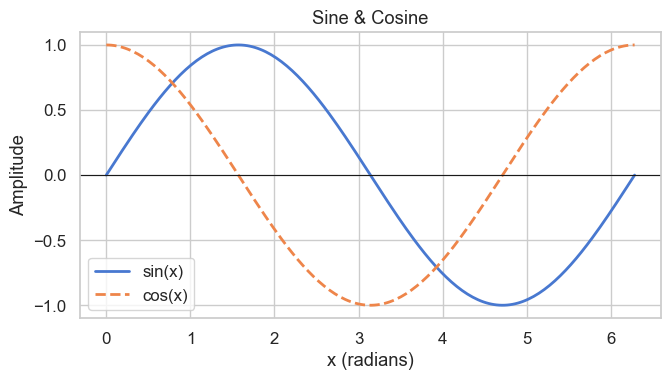

In [2]:
fig, ax = plt.subplots(figsize=(7, 4))
x = np.linspace(0, 2 * np.pi, 200)
ax.plot(x, np.sin(x), label='sin(x)', lw=2)
ax.plot(x, np.cos(x), label='cos(x)', lw=2, linestyle='--')
ax.set_title('Sine & Cosine')
ax.set_xlabel('x (radians)')
ax.set_ylabel('Amplitude')
ax.legend()
ax.axhline(0, color='k', lw=0.8)  # horizontal reference line
plt.tight_layout()
plt.show()

## 2. Subplots grid

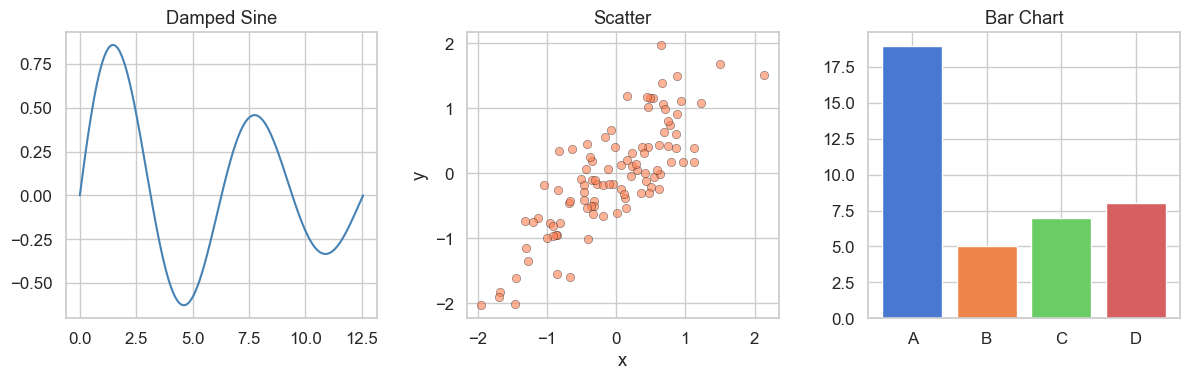

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# (a) Line plot
t = np.linspace(0, 4 * np.pi, 300)
axes[0].plot(t, np.sin(t) * np.exp(-t / 10), color='steelblue')
axes[0].set_title('Damped Sine')

# (b) Scatter plot
x = rng.normal(0, 1, 100)
y = 0.8 * x + rng.normal(0, 0.5, 100)
axes[1].scatter(x, y, alpha=0.6, edgecolors='k', linewidths=0.4, color='coral')
axes[1].set_title('Scatter')
axes[1].set_xlabel('x'); axes[1].set_ylabel('y')

# (c) Bar chart
cats = ['A', 'B', 'C', 'D']
vals = rng.integers(5, 20, size=4)
axes[2].bar(cats, vals, color=sns.color_palette('muted', 4))
axes[2].set_title('Bar Chart')

plt.tight_layout()
plt.show()

## 3. Histograms & KDE — understanding distributions

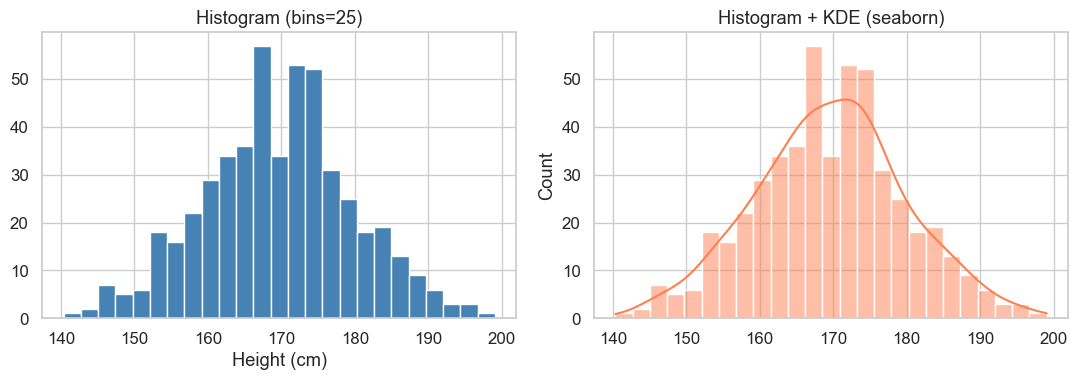

In [4]:
data = rng.normal(loc=170, scale=10, size=500)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Histogram
axes[0].hist(data, bins=25, edgecolor='white', color='steelblue')
axes[0].set_title('Histogram (bins=25)')
axes[0].set_xlabel('Height (cm)')

# Seaborn histplot with KDE overlay
sns.histplot(data, bins=25, kde=True, ax=axes[1], color='coral')
axes[1].set_title('Histogram + KDE (seaborn)')

plt.tight_layout()
plt.show()

## 4. Box & violin plots — comparing groups

/var/folders/fq/_gb_05js7kl2bnvct1k4p39m0000gn/T/ipykernel_84189/501902702.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='group', y='score', ax=axes[0], palette='muted')
/var/folders/fq/_gb_05js7kl2bnvct1k4p39m0000gn/T/ipykernel_84189/501902702.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='group', y='score', ax=axes[1], palette='muted', inner='quartile')


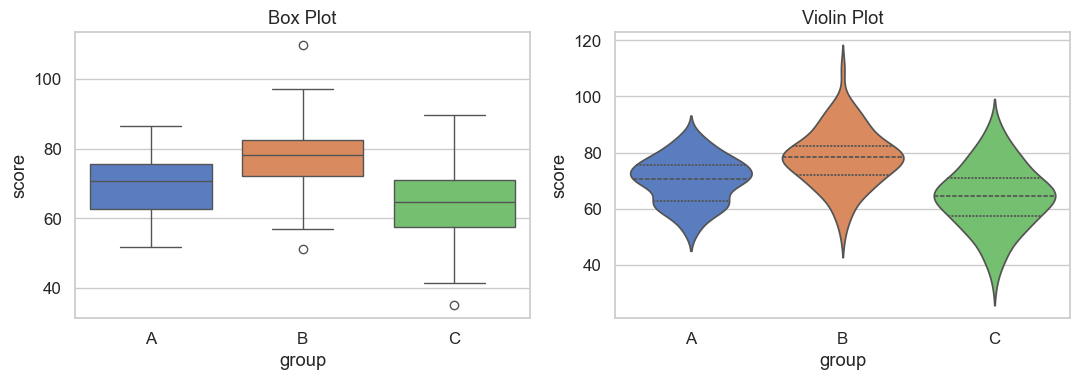

In [5]:
# Build a small sample dataset
df = pd.DataFrame({
    'score': np.concatenate([
        rng.normal(70, 8, 80),
        rng.normal(78, 10, 80),
        rng.normal(65, 12, 80),
    ]),
    'group': ['A'] * 80 + ['B'] * 80 + ['C'] * 80,
})

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.boxplot(data=df, x='group', y='score', ax=axes[0], palette='muted')
axes[0].set_title('Box Plot')

sns.violinplot(data=df, x='group', y='score', ax=axes[1], palette='muted', inner='quartile')
axes[1].set_title('Violin Plot')

plt.tight_layout()
plt.show()

## 5. Heatmaps — correlation matrices

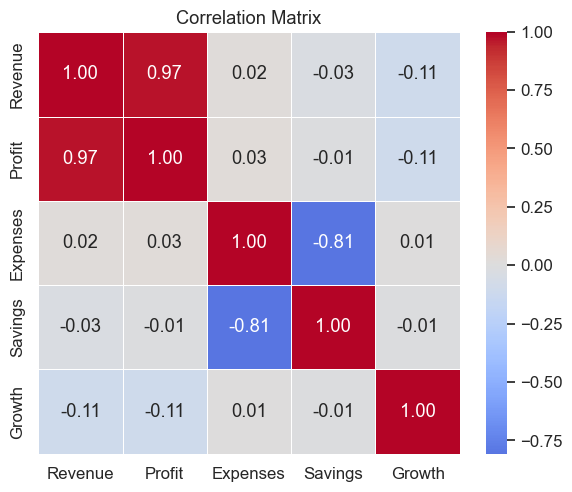

In [6]:
# Simulate a dataset with 5 features
raw = rng.normal(size=(200, 5))
# Introduce some correlations
raw[:, 1] = 0.8 * raw[:, 0] + 0.2 * raw[:, 1]
raw[:, 3] = -0.6 * raw[:, 2] + 0.4 * raw[:, 3]
feat_df = pd.DataFrame(raw, columns=['Revenue', 'Profit', 'Expenses', 'Savings', 'Growth'])

corr = feat_df.corr().round(2)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, square=True, ax=ax)
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.show()

## 6. Seaborn pair plot — seeing everything at once

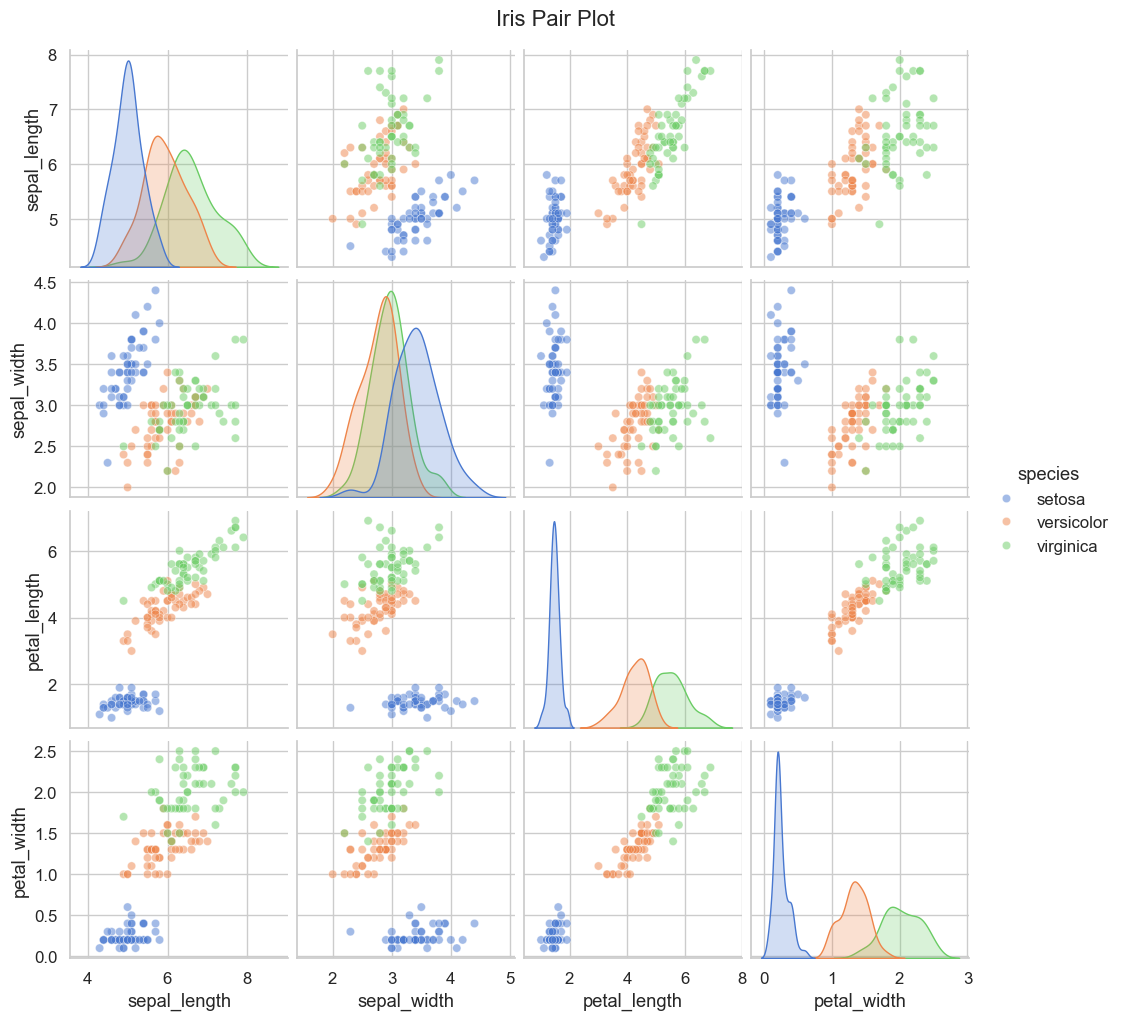

In [7]:
# Use the built-in iris dataset
iris = sns.load_dataset('iris')
sns.pairplot(iris, hue='species', diag_kind='kde', plot_kws={'alpha': 0.5})
plt.suptitle('Iris Pair Plot', y=1.02)
plt.show()

## 7. Time series visualization

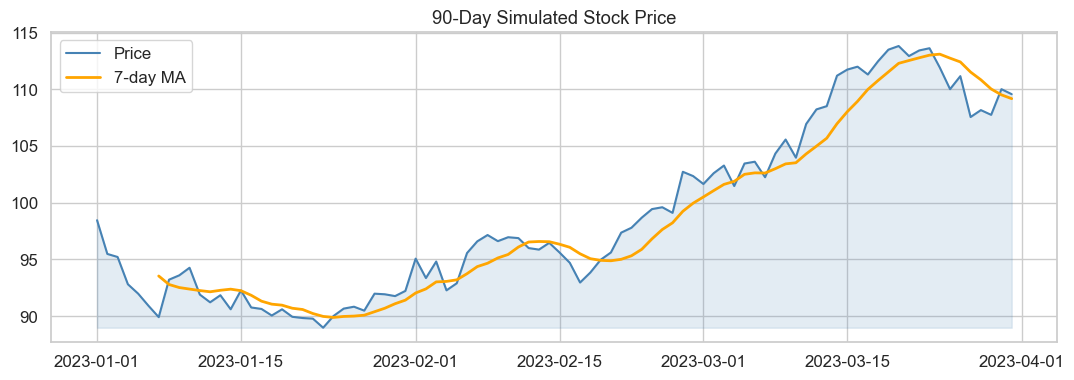

In [8]:
dates = pd.date_range('2023-01-01', periods=90, freq='D')
ts = pd.Series(
    np.cumsum(rng.normal(0.3, 1.5, 90)),
    index=dates,
    name='stock_price'
) + 100

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(ts, lw=1.5, color='steelblue', label='Price')
ax.fill_between(ts.index, ts.min(), ts, alpha=0.15, color='steelblue')
roll = ts.rolling(7).mean()
ax.plot(roll, lw=2, color='orange', label='7-day MA')
ax.set_title('90-Day Simulated Stock Price')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Styling & saving figures

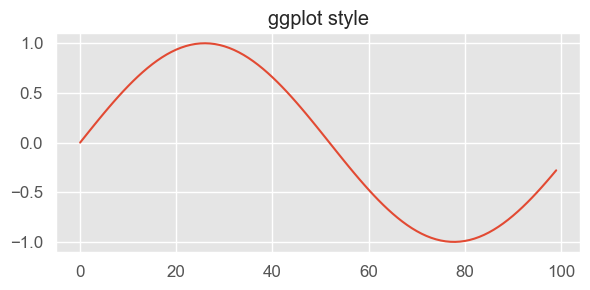

Saved to /tmp/demo.png


In [9]:
# Use a built-in style temporarily
with plt.style.context('ggplot'):
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.plot(np.sin(np.linspace(0, 6, 100)))
    ax.set_title('ggplot style')
    plt.tight_layout()
    # Save at high DPI (great for reports)
    fig.savefig('/tmp/demo.png', dpi=150, bbox_inches='tight')
    plt.show()
print('Saved to /tmp/demo.png')